# Phase 2 — Notebook 09 · Multichannel E1 Design B (calcium + time-varying stimulus + behaviour, *no* hash embeddings)

**What this notebook does.** Multichannel E1 Design B that classifies each neuron from the *set* of its oracle-hash trial-averaged calcium responses, augmented with **time-varying** per-frame stimulus channels and **time-varying** trial-averaged behaviour channels. There are **no hash embeddings**. The interpretable per-frame stimulus features replace the categorical hash identity used in NBs 04 / 07 / 08.

**What changed compared to the previous version of this notebook.**

1. **Stimulus channels are now time-varying**, not constant. Previously we broadcast the 10 scalar Tier-D descriptors as constant time channels. Now we compute 7 per-frame features directly from the raw oracle videos via `MicronsFunctionalReader.get_video_data(hash)`:
   * `stim_lum_mean(t)` — per-frame mean pixel intensity
   * `stim_lum_std(t)` — per-frame pixel-intensity std
   * `stim_norm_contrast(t)` — std / mean per frame
   * `stim_motion_energy(t)` — `|frame[t] − frame[t-1]|` mean
   * `stim_grad_energy(t)` — mean magnitude of the spatial gradient
   * `stim_edge_frac(t)` — fraction of pixels above the 85th-pct gradient
   * `stim_center_surround(t)` — centre minus surround mean intensity

   Each channel has the same temporal length as the calcium trace (Clip → 75 frames, Monet2/Trippy → 113 frames, padded to 113 with zero exactly like `response_avg`). Computation is cached to disk after the first run.

2. **Calcium-only baselines are loaded from previous notebooks**, not retrained:
   * Part A baseline ← NB 04 `phase2_stage2_2a_hash_aware_design_b.parquet` (mean + attention pool, hash-aware Design B on session 5_6).
   * Part B baseline ← NB 07 `phase2_stage2_3_pooled_gkf_balanced.parquet` (attention pool, hash-aware Design B pooled GKF).
   * Part C baseline ← NB 08 `phase2_stage2_3_loso_balanced.parquet` (attention pool, hash-aware Design B LOSO).

   The baselines are *hash-aware* (they use a learned hash embedding). The Δ between the multichannel-no-hash model and the hash-aware baseline therefore measures whether *interpretable time-varying stimulus + behaviour channels* can replace the categorical hash table — which is the scientific question of this notebook.

3. **LOSO behaviour normalisation now uses training sessions only.** For each held-out session $s$, the mean and std used to z-score the behaviour channels are computed from `(session, hash)` entries with `session ≠ s`, then applied to all entries (train + held-out test). The held-out session's behaviour distribution is *not* allowed to leak into the standardisation statistics. Stimulus channels are session-invariant by construction (same hash → same per-frame video features) so their normalisation is fold-independent.

**Architecture (planning §6.3 — Design B, no hash table).** For each neuron $i$ and oracle hash $h$ we build a multichannel time-series tensor

$$
x_{i,h} \in \mathbb{R}^{C \times T},\qquad C = 1 + 7 + 2 = 10,\;\; T = 113,
$$

with channel 0 = calcium, channels 1–7 = per-frame stimulus, channels 8–9 = behaviour (treadmill, pupil_dilation). The shared trace encoder produces a per-trace embedding $e_{i,h} = \text{Encoder}(x_{i,h})$, the embeddings are pooled across hashes with **mean** or **attention** pool, and the head classifies once per neuron. The model class is `DeepSetsTraceCNN` (no hash embedding) with `in_channels = 10`.

**Three-part protocol** (per the user's brief):

* **Part A — within-session 5_6.** GroupKFold(5) by `nucleus_id`. Compared paired against NB 04 hash-aware mean and attention pool.
* **Part B — pooled GroupKFold across 6 balanced sessions** (`5_6, 5_7, 6_2, 6_4, 6_6, 6_7`). Compared against NB 07 hash-aware attention pool.
* **Part C — LOSO across the same 6 sessions.** Compared against NB 08 hash-aware attention pool. Behaviour channels are standardised using only the training sessions of each fold.

Outputs:
* `data/processed/results/phase2_multichannel_within_session.parquet` (Part A)
* `data/processed/results/phase2_multichannel_pooled_gkf.parquet` (Part B)
* `data/processed/results/phase2_multichannel_loso.parquet` (Part C)
* Cache: `data/processed/features/per_frame_stim_oracle.npz`

## 0 · Environment

In [1]:
import os, sys, time, warnings
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import GroupKFold
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix

from src.config import PROCESSED_RESULTS_DIR, PROCESSED_FEATURES_DIR
from src.data.loaders import load_working_pop
from src.features.raw_traces import (
    remove_mismatch_neurons,
    build_single_session_e1,
    build_pooled_e1,
    load_oracle_hashes,
    load_behaviour_channels_e1,
    load_stimulus_channels_e1_timevarying,
    merge_channel_maps,
    zscore_behaviour_for_loso_fold,
    MAX_TRACE_LEN,
)
from src.features.tier_d import PER_FRAME_STIM_CHANNELS
from src.models.cnn import LAYER_CLASSES
from src.models.cnn_deepsets import (
    DeepSetsTraceCNN,
    build_e1_neuron_tensors,
    build_e1_neuron_tensors_with_hashes,
    build_e1_neuron_tensors_multichannel,
    train_design_b_fold,
    predict_neuron_proba,
    neuron_score_design_b,
)
from src.eval.cnn_eval import save_results, make_result_row

warnings.filterwarnings('ignore', category=UserWarning)

# ---- Global config ---------------------------------------------------------
SEED        = 42
N_FOLDS     = 5
MAX_EPOCHS  = 50
PATIENCE    = 8
BATCH_SIZE  = 32
EMBED_DIM   = 64
HEAD_HIDDEN = 64
DROPOUT     = 0.25
KERNEL_SIZE = 5

SESSION_A         = '5_6'
BALANCED_SESSIONS = ['5_6', '5_7', '6_2', '6_4', '6_6', '6_7']

# Channels — calcium is always position 0; stim then behaviour after it
STIM_CHANNELS = list(PER_FRAME_STIM_CHANNELS)              # 7 time-varying
BEH_CHANNELS  = ['treadmill', 'pupil_dilation']            # 2 time-varying
ALL_EXTRA_CHANNELS = STIM_CHANNELS + BEH_CHANNELS          # 9 → C = 10
C_TOTAL = 1 + len(ALL_EXTRA_CHANNELS)

POOL_VARIANTS = ['mean', 'attention']

# Per-frame video features cache (computed once on first run)
STIM_CACHE = PROCESSED_FEATURES_DIR / 'per_frame_stim_oracle.npz'

# Baseline parquet locations (hash-aware Design B from previous notebooks)
NB04_PARQUET = Path('data/processed/results/phase2_stage2_2a_hash_aware_design_b.parquet')
NB07_PARQUET = Path('data/processed/results/phase2_stage2_3_pooled_gkf_balanced.parquet')
NB08_PARQUET = Path('data/processed/results/phase2_stage2_3_loso_balanced.parquet')

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device                 : {DEVICE}')
print(f'Total input channels   : 1 (calcium) + {len(STIM_CHANNELS)} stim (time-varying) + '
      f'{len(BEH_CHANNELS)} beh (time-varying) = {C_TOTAL}')
print(f'Stimulus channels      : {STIM_CHANNELS}')
print(f'Behaviour channels     : {BEH_CHANNELS}')
print(f'Pool variants          : {POOL_VARIANTS}')
print(f'Part A session         : {SESSION_A}')
print(f'Part B / C subset      : {BALANCED_SESSIONS}')
print(f'Stim cache             : {STIM_CACHE}')

Device                 : mps
Total input channels   : 1 (calcium) + 7 stim (time-varying) + 2 beh (time-varying) = 10
Stimulus channels      : ['stim_lum_mean', 'stim_lum_std', 'stim_norm_contrast', 'stim_motion_energy', 'stim_grad_energy', 'stim_edge_frac', 'stim_center_surround']
Behaviour channels     : ['treadmill', 'pupil_dilation']
Pool variants          : ['mean', 'attention']
Part A session         : 5_6
Part B / C subset      : ['5_6', '5_7', '6_2', '6_4', '6_6', '6_7']
Stim cache             : data/processed/features/per_frame_stim_oracle.npz


## 0a · Helpers — baseline loaders, multichannel inference, reporting

The calcium-only baseline in each part is the corresponding *hash-aware* Design B trained in NBs 04 / 07 / 08. Because the baseline uses categorical hash embeddings and the multichannel model uses interpretable time-varying stim + beh channels (no hash embeddings), the Δ measures the value of *replacing* the categorical hash table with feature-aligned channels.

In [2]:
def load_baseline_rows(parquet_path, model_name_filter=None,
                        contains_filter=None, fold_filter='fold'):
    """Load fold-level rows from a baseline parquet.

    Returns a DataFrame sorted by fold or session. Filters can be either an
    exact `model_name` string or a substring `contains_filter` (matched
    case-insensitive). `fold_filter` is a substring expected in
    `fold_or_session` to keep only fold/session rows (drops the summary row).
    """
    if not Path(parquet_path).exists():
        return None
    df = pd.read_parquet(parquet_path)
    sub = df.copy()
    if model_name_filter is not None:
        sub = sub[sub['model_name'] == model_name_filter]
    if contains_filter is not None:
        sub = sub[sub['model_name'].str.contains(contains_filter, case=False, na=False)]
    if fold_filter is not None:
        sub = sub[sub['fold_or_session'].str.contains(fold_filter, case=False, na=False)]
    return sub.reset_index(drop=True) if len(sub) else None


def neuron_score_with_dist(y_true, probs, classes=None):
    score = neuron_score_design_b(y_true, probs, classes=classes)
    cls = score['classes']
    pred_dist = pd.Series(score['y_neuron_pred']).value_counts().reindex(cls, fill_value=0)
    score['predicted_class_distribution'] = pred_dist.to_dict()
    return score


def per_class_precision_f1(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    prec, f1c = {}, {}
    for i, c in enumerate(classes):
        denom_p = cm[:, i].sum()
        prec[str(c)] = float(cm[i, i] / denom_p) if denom_p > 0 else float('nan')
        rec_i = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else float('nan')
        if (rec_i + prec[str(c)]) > 0 and np.isfinite(rec_i + prec[str(c)]):
            f1c[str(c)] = float(2 * rec_i * prec[str(c)] / (rec_i + prec[str(c)]))
        else:
            f1c[str(c)] = float('nan')
    return prec, f1c


def summarise(scores):
    bas = np.array([s['balanced_accuracy'] for s in scores])
    f1s = np.array([s['macro_f1']          for s in scores])
    pcr = {c: np.array([s['per_class_recall'][c] for s in scores]) for c in LAYER_CLASSES}
    return {'bal_acc': bas, 'macro_f1': f1s, 'recall': pcr}


def fmt_arr(a):    return f'{a.mean():.4f} ± {a.std(ddof=0):.4f}'
def fmt_recall(a): return f'{np.nanmean(a):.3f} ± {np.nanstd(a):.3f}'

print('Helpers ready.')

Helpers ready.


## 0b · Per-frame stimulus channels (computed once, cached, shared across A/B/C)

These channels depend only on the oracle hash, not on the session, so the same per-frame arrays apply to every session. Computed once on the union of sessions used in this notebook and written to the cache for reuse.

In [3]:
oracle_hashes, _ = load_oracle_hashes()
HASH_VOCAB = sorted(oracle_hashes)
N_HASHES   = len(HASH_VOCAB)

t0 = time.time()
stim_map_all = load_stimulus_channels_e1_timevarying(
    BALANCED_SESSIONS, pad_to=MAX_TRACE_LEN,
    standardize=True, cache_path=STIM_CACHE, verbose=True,
)
print(f'Per-frame stim build / load: {time.time() - t0:.1f}s')
print(f'Sample entry shape: {next(iter(stim_map_all.values()))[STIM_CHANNELS[0]].shape}')
# Quick channel-range sanity print
for ch in STIM_CHANNELS:
    vals = np.concatenate([d[ch] for d in stim_map_all.values()])
    print(f'  {ch:<22s}: min={vals.min():+.3f}  max={vals.max():+.3f}  '
          f'mean={vals.mean():+.3f}  std={vals.std():.3f}')

Computing per-frame stim features for 116 oracle hashes (this is slow on first run; subsequent calls hit the cache)...
  [per-frame stim] 50/116 hashes processed …
  [per-frame stim] 100/116 hashes processed …
  Cached → data/processed/features/per_frame_stim_oracle.npz
  Standardised 7 per-frame stim channels (z-score across hashes × time).
  Per-frame stim map: 696 (session, hash) pairs across 6 session(s); channels = ['stim_lum_mean', 'stim_lum_std', 'stim_norm_contrast', 'stim_motion_energy', 'stim_grad_energy', 'stim_edge_frac', 'stim_center_surround']
Per-frame stim build / load: 5.4s
Sample entry shape: (113,)
  stim_lum_mean         : min=-1.223  max=+3.423  mean=-0.000  std=1.000
  stim_lum_std          : min=-1.226  max=+2.064  mean=-0.000  std=1.000
  stim_norm_contrast    : min=-1.138  max=+7.743  mean=+0.000  std=1.000
  stim_motion_energy    : min=-0.808  max=+4.133  mean=-0.000  std=1.000
  stim_grad_energy      : min=-0.951  max=+3.982  mean=+0.000  std=1.000
  stim_edg

# Part A — within-session 5_6

GroupKFold(5) by `nucleus_id`. Multichannel mean + attention pool. Calcium-only baseline is loaded from NB 04 (hash-aware Design B) — not retrained.

## A.1 · Population, single-session E1, channel maps (Part A)

In [4]:
units_raw = load_working_pop()
units_clean, _ = remove_mismatch_neurons(units_raw, verbose=False)
df_A = build_single_session_e1(SESSION_A, units_clean, verbose=False)

# Drop neurons without all 116 oracle hashes (set-tensor builder requires uniformity)
cov = df_A.groupby('nucleus_id')['condition_hash'].nunique()
df_A = df_A[df_A['nucleus_id'].isin(cov.index[cov == 116])].copy()
print(f'{SESSION_A}: {df_A["nucleus_id"].nunique()} clean neurons × 116 hashes = {len(df_A):,} rows')

# Behaviour map for session 5_6 — kept un-z-scored so Part C can normalize per-fold
beh_map_A = load_behaviour_channels_e1([SESSION_A], channels=BEH_CHANNELS,
                                        pad_to=MAX_TRACE_LEN, verbose=True)

# Within Part A there is no LOSO concern, so we can z-score behaviour using all
# (session, hash) entries here (single session ⇒ training set = all of 5_6).
# This is equivalent to "training-only" because we never have a held-out session.
print('\nStandardising behaviour channels for Part A:')
for ch in BEH_CHANNELS:
    vals = np.concatenate([d[ch] for d in beh_map_A.values()])
    mu = float(np.nanmean(vals)); sd = float(np.nanstd(vals)) or 1.0
    print(f'  {ch}: mu={mu:+.4f}  sd={sd:.4f}')
    for k in beh_map_A:
        beh_map_A[k][ch] = ((beh_map_A[k][ch] - mu) / sd).astype(np.float32)

# Restrict the global stim map to session 5_6 entries
stim_map_A = {k: v for k, v in stim_map_all.items() if k[0] == SESSION_A}

# Merge
chan_map_A = merge_channel_maps(stim_map_A, beh_map_A)
print(f'\nMerged Part A channel map: {len(chan_map_A)} (session, hash) entries')

5_6: 685 clean neurons × 116 hashes = 79,460 rows
Loading behaviour channels ['treadmill', 'pupil_dilation'] for sessions=['5_6'] ...
  trials_meta rows: 280
  trial-averaged (session, hash) pairs: 116 (of 116 possible)
  channel 'treadmill': range [-5.911, 8.693], mean 0.003
  channel 'pupil_dilation': range [0.000, 82.506], mean 36.870

Standardising behaviour channels for Part A:
  treadmill: mu=+0.0031  sd=0.1311
  pupil_dilation: mu=+36.8696  sd=24.6408

Merged Part A channel map: 116 (session, hash) entries


/Users/katiarusso/Documents/VS CODE/Classes/Neuroscience/Final Project/src/features/raw_traces.py:844: RuntimeWarning: Mean of empty slice
  avg = np.nanmean(stacked, axis=0)


## A.2 · Set tensor `(N, 116, 10, 113)` and GKF folds

In [5]:
X_A, mask_A, y_A, nids_A, hash_ids_A, _hash_vocab, channel_names_A = (
    build_e1_neuron_tensors_multichannel(
        df_A, chan_map_A, channel_names=ALL_EXTRA_CHANNELS,
        pad_to=MAX_TRACE_LEN, hash_vocab=HASH_VOCAB,
    )
)
print(f'X_A      shape : {X_A.shape}     (N, H, C, T)')
print(f'channels       : {channel_names_A}')

neurons_A = pd.DataFrame({'nucleus_id': nids_A, 'layer_label': y_A})
gkf = GroupKFold(n_splits=N_FOLDS)
fold_of_A = np.full(len(nids_A), -1, dtype=np.int8)
for k, (_, te_idx) in enumerate(gkf.split(nids_A, groups=nids_A)):
    fold_of_A[te_idx] = k
print('\nNeurons per fold × layer (Part A):')
print(pd.crosstab(fold_of_A, y_A, rownames=['fold']).to_string())

X_A      shape : (685, 116, 10, 113)     (N, H, C, T)
channels       : ['calcium', 'stim_lum_mean', 'stim_lum_std', 'stim_norm_contrast', 'stim_motion_energy', 'stim_grad_energy', 'stim_edge_frac', 'stim_center_surround', 'treadmill', 'pupil_dilation']

Neurons per fold × layer (Part A):
col_0  L2/3  L4  L5  L6
fold                   
0        32  50  36  19
1        29  51  37  20
2        29  52  37  19
3        29  49  40  19
4        32  47  39  19


## A.3 · Per-fold runner — Design B *without* hash embeddings (multichannel)

In [6]:
def run_design_b_fold(X, mask, y, fold_of, fold_k, *,
                      in_channels, pool, seed=SEED, verbose=False):
    val_k = (fold_k + 1) % N_FOLDS
    test_idx  = np.where(fold_of == fold_k)[0]
    val_idx   = np.where(fold_of == val_k)[0]
    train_idx = np.where(~np.isin(fold_of, [fold_k, val_k]))[0]
    assert not (set(train_idx) & set(val_idx)), 'train ∩ val'
    assert not (set(train_idx) & set(test_idx)), 'train ∩ test'
    assert not (set(val_idx)   & set(test_idx)), 'val ∩ test'

    X_tr, M_tr, y_tr = X[train_idx], mask[train_idx], y[train_idx]
    X_va, M_va, y_va = X[val_idx],   mask[val_idx],   y[val_idx]
    X_te, M_te, y_te = X[test_idx],  mask[test_idx],  y[test_idx]

    model, history = train_design_b_fold(
        X_tr, M_tr, y_tr, X_va, M_va, y_va,
        in_channels=in_channels, n_classes=4,
        embed_dim=EMBED_DIM, head_hidden=HEAD_HIDDEN,
        dropout=DROPOUT, kernel_size=KERNEL_SIZE,
        pool=pool,
        batch_size=BATCH_SIZE, max_epochs=MAX_EPOCHS, patience=PATIENCE,
        lr=1e-3, weight_decay=1e-4,
        seed=seed + fold_k, device=DEVICE, verbose=verbose,
    )

    test_probs = predict_neuron_proba(model, X_te, mask=M_te,
                                      batch_size=BATCH_SIZE, device=DEVICE)
    val_probs  = predict_neuron_proba(model, X_va, mask=M_va,
                                      batch_size=BATCH_SIZE, device=DEVICE)
    score = neuron_score_with_dist(y_te, test_probs, classes=np.array(LAYER_CLASSES))

    val_pred = np.array(LAYER_CLASSES)[val_probs.argmax(axis=1)]
    score['val_balanced_accuracy'] = float(balanced_accuracy_score(y_va, val_pred))
    score['val_macro_f1']          = float(f1_score(y_va, val_pred, average='macro',
                                                     labels=LAYER_CLASSES, zero_division=0))
    score['val_minus_test_gap']    = score['val_balanced_accuracy'] - score['balanced_accuracy']
    score['best_epoch']   = int(np.argmax([h['val_bal_acc'] for h in history])) + 1
    score['n_epochs_run'] = len(history)
    prec, f1c = per_class_precision_f1(y_te, score['y_neuron_pred'], np.array(LAYER_CLASSES))
    score['per_class_precision'] = prec
    score['per_class_f1']        = f1c
    return score, history

print('Design-B (no hash embedding) per-fold runner ready.')

Design-B (no hash embedding) per-fold runner ready.


## A.4 · Run Part A — multichannel mean & attention pool

In [ ]:
resultsA   = {}        # {pool: [score per fold]}
historiesA = {}

t0 = time.time()
for pool in POOL_VARIANTS:
    print(f'\n──── Part A · multichannel · pool={pool} · in_channels={C_TOTAL} ────')
    resultsA[pool]   = []
    historiesA[pool] = []
    for k in range(N_FOLDS):
        ti = time.time()
        score, hist = run_design_b_fold(
            X_A, mask_A, y_A, fold_of_A, fold_k=k,
            in_channels=C_TOTAL, pool=pool, seed=SEED, verbose=False,
        )
        score['fold'] = k
        resultsA[pool].append(score)
        historiesA[pool].append(hist)
        ba = score['balanced_accuracy']; f1 = score['macro_f1']
        pcr = score['per_class_recall']
        print(f'  fold {k} | n_test={score["n_neurons"]:3d} | '
              f'bal_acc={ba:.4f} F1={f1:.4f}  '
              f'val−test gap={score["val_minus_test_gap"]:+.3f}  '
              f'L23={pcr["L2/3"]:.2f} L4={pcr["L4"]:.2f} L5={pcr["L5"]:.2f} L6={pcr["L6"]:.2f}  '
              f'best_ep={score["best_epoch"]:>2d}/{score["n_epochs_run"]}  '
              f'({time.time() - ti:.1f}s)')
print(f'\nPart A total training time: {(time.time() - t0) / 60:.1f} min')


──── Part A · multichannel · pool=mean · in_channels=10 ────
  fold 0 | n_test=137 | bal_acc=0.5630 F1=0.5273  val−test gap=-0.021  L23=0.19 L4=0.62 L5=0.44 L6=1.00  best_ep=15/23  (33.8s)
  fold 1 | n_test=137 | bal_acc=0.5170 F1=0.4598  val−test gap=+0.009  L23=0.00 L4=0.63 L5=0.54 L6=0.90  best_ep=21/29  (38.9s)
  fold 2 | n_test=137 | bal_acc=0.5348 F1=0.4958  val−test gap=+0.064  L23=0.10 L4=0.52 L5=0.62 L6=0.89  best_ep=30/38  (81.0s)
  fold 3 | n_test=137 | bal_acc=0.4587 F1=0.3607  val−test gap=+0.018  L23=0.17 L4=0.61 L5=0.05 L6=1.00  best_ep= 2/10  (21.2s)
  fold 4 | n_test=137 | bal_acc=0.5154 F1=0.4502  val−test gap=+0.071  L23=0.09 L4=0.53 L5=0.44 L6=1.00  best_ep=15/23  (46.8s)

──── Part A · multichannel · pool=attention · in_channels=10 ────
  fold 0 | n_test=137 | bal_acc=0.5775 F1=0.5461  val−test gap=+0.048  L23=0.25 L4=0.56 L5=0.50 L6=1.00  best_ep=15/23  (45.1s)
  fold 1 | n_test=137 | bal_acc=0.5689 F1=0.5431  val−test gap=-0.014  L23=0.28 L4=0.45 L5=0.65 L6=0.90

## A.5 · Load NB 04 hash-aware baseline (paired comparison)

The baseline is hash-aware Design B trained on the same session 5_6 with the same GKF(5) protocol. Mean and attention pool variants both exist in `phase2_stage2_2a_hash_aware_design_b.parquet`.

In [8]:
baselineA = {}     # {pool: DataFrame with 5 fold rows}
for pool in POOL_VARIANTS:
    suffix = 'attnpool' if pool == 'attention' else 'meanpool'
    sub = load_baseline_rows(
        NB04_PARQUET,
        model_name_filter=f'HashAwareDeepSetsCNN_E1_raw_identity_{suffix}',
        fold_filter='fold',
    )
    if sub is None or len(sub) < N_FOLDS:
        print(f'⚠ NB 04 {pool}-pool baseline not found in {NB04_PARQUET} '
              f'or has < {N_FOLDS} fold rows.')
        baselineA[pool] = None
    else:
        sub = sub.sort_values('fold_or_session').reset_index(drop=True).iloc[:N_FOLDS]
        baselineA[pool] = sub
        print(f'NB 04 {pool}-pool baseline ({len(sub)} rows): '
              f"bal_acc = {sub['balanced_accuracy'].mean():.4f} ± "
              f"{sub['balanced_accuracy'].std(ddof=0):.4f}")

NB 04 mean-pool baseline (5 rows): bal_acc = 0.5247 ± 0.0355
NB 04 attention-pool baseline (5 rows): bal_acc = 0.5685 ± 0.0311


## A.6 · Summary table & paired Δ vs NB 04 hash-aware baseline

In [9]:
summariesA = {pool: summarise(scores) for pool, scores in resultsA.items()}

rows = []
for pool in POOL_VARIANTS:
    sm = summariesA[pool]
    rows.append({
        'config': f'multichannel_no_hash · {pool}',
        'channels': C_TOTAL,
        'bal_acc':  fmt_arr(sm['bal_acc']),
        'macro_F1': fmt_arr(sm['macro_f1']),
        'L2/3':     fmt_recall(sm['recall']['L2/3']),
        'L4':       fmt_recall(sm['recall']['L4']),
        'L5':       fmt_recall(sm['recall']['L5']),
        'L6':       fmt_recall(sm['recall']['L6']),
    })
    if baselineA[pool] is not None:
        b = baselineA[pool]
        rows.append({
            'config': f'NB 04 hash-aware (calcium-only) · {pool}',
            'channels': 1,
            'bal_acc':  f"{b['balanced_accuracy'].mean():.4f} ± {b['balanced_accuracy'].std(ddof=0):.4f}",
            'macro_F1': f"{b['macro_f1'].mean():.4f} ± {b['macro_f1'].std(ddof=0):.4f}",
            'L2/3':     f"{b['recall_L23'].mean():.3f} ± {b['recall_L23'].std(ddof=0):.3f}",
            'L4':       f"{b['recall_L4'].mean():.3f} ± {b['recall_L4'].std(ddof=0):.3f}",
            'L5':       f"{b['recall_L5'].mean():.3f} ± {b['recall_L5'].std(ddof=0):.3f}",
            'L6':       f"{b['recall_L6'].mean():.3f} ± {b['recall_L6'].std(ddof=0):.3f}",
        })
print(f'NB 09 · Part A (within session {SESSION_A}, GKF{N_FOLDS})\n')
print(pd.DataFrame(rows).set_index('config').to_string())

print('\nPaired Δ (multichannel − NB 04 hash-aware baseline), same pool, same fold index:')
for pool in POOL_VARIANTS:
    if baselineA[pool] is None:
        continue
    sm = summariesA[pool]
    b  = baselineA[pool]
    d_ba = sm['bal_acc']  - b['balanced_accuracy'].to_numpy()[:N_FOLDS]
    d_f1 = sm['macro_f1'] - b['macro_f1'].to_numpy()[:N_FOLDS]
    d_rec = {c: sm['recall'][c] - b[f'recall_{c.replace("/","")}']
                                   .to_numpy()[:N_FOLDS] for c in LAYER_CLASSES}
    rows = []
    for metric, d in [('balanced_accuracy', d_ba), ('macro_F1', d_f1)] + \
                     [(f'recall_{c}', d_rec[c]) for c in LAYER_CLASSES]:
        rows.append({
            'metric': metric,
            **{f'fold{i}': f'{d[i]:+.3f}' for i in range(N_FOLDS)},
            'mean Δ': f'{d.mean():+.4f}',
            'std Δ':  f'{d.std(ddof=0):.4f}',
            'n_pos/5': int((d > 0).sum()),
        })
    print(f'\n  pool = {pool}')
    print(pd.DataFrame(rows).set_index('metric').to_string())

NB 09 · Part A (within session 5_6, GKF5)

                                             channels          bal_acc         macro_F1           L2/3             L4             L5             L6
config                                                                                                                                             
multichannel_no_hash · mean                        10  0.5178 ± 0.0342  0.4588 ± 0.0561  0.111 ± 0.067  0.582 ± 0.047  0.419 ± 0.196  0.959 ± 0.050
NB 04 hash-aware (calcium-only) · mean              1  0.5247 ± 0.0355  0.4689 ± 0.0552  0.169 ± 0.190  0.439 ± 0.235  0.606 ± 0.084  0.886 ± 0.038
multichannel_no_hash · attention                   10  0.5534 ± 0.0221  0.5211 ± 0.0212  0.186 ± 0.087  0.570 ± 0.078  0.583 ± 0.078  0.875 ± 0.118
NB 04 hash-aware (calcium-only) · attention         1  0.5685 ± 0.0311  0.5252 ± 0.0343  0.060 ± 0.046  0.648 ± 0.121  0.638 ± 0.163  0.927 ± 0.063

Paired Δ (multichannel − NB 04 hash-aware baseline), same pool, same

## A.7 · Plots — per-fold bal-acc, per-class recall, confusion matrices, training curves

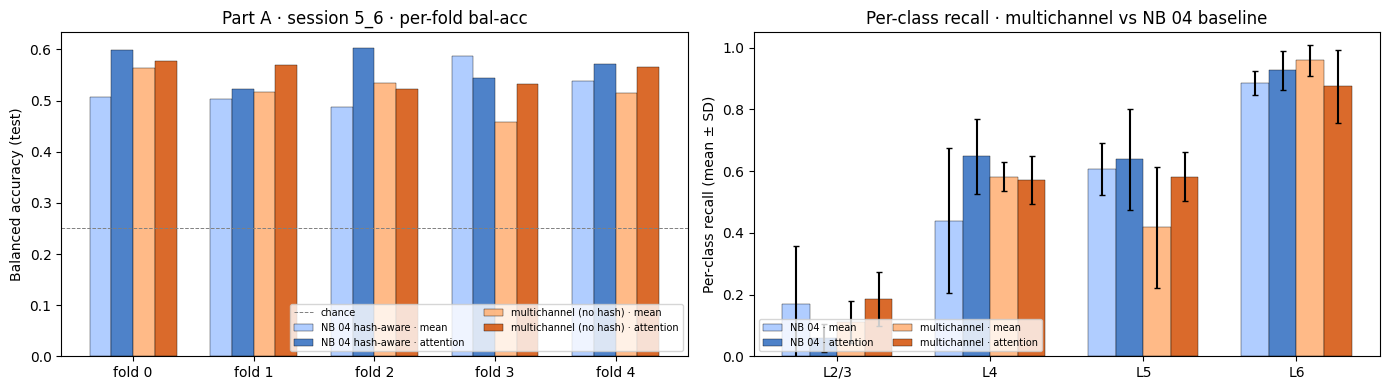

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
x = np.arange(N_FOLDS); width = 0.18
colors = {('multichannel','mean'):'#ffb37a',
          ('multichannel','attention'):'#d65a14',
          ('NB04','mean'):'#a8c8ff',
          ('NB04','attention'):'#3b75c4'}
i = 0
all_bars = []
for cond in ['NB04', 'multichannel']:
    for pool in POOL_VARIANTS:
        if cond == 'NB04':
            if baselineA[pool] is None: i += 1; continue
            bars = baselineA[pool]['balanced_accuracy'].to_numpy()[:N_FOLDS]
            label = f'NB 04 hash-aware · {pool}'
        else:
            bars = summariesA[pool]['bal_acc']
            label = f'multichannel (no hash) · {pool}'
        offset = (i - 1.5) * width
        ax.bar(x + offset, bars, width, label=label,
                color=colors.get((cond, pool), f'C{i}'),
                alpha=0.9, edgecolor='k', linewidth=0.3)
        i += 1
ax.axhline(0.25, color='gray', ls='--', lw=0.7, label='chance')
ax.set_xticks(x); ax.set_xticklabels([f'fold {k}' for k in range(N_FOLDS)])
ax.set_ylabel('Balanced accuracy (test)')
ax.set_title(f'Part A · session {SESSION_A} · per-fold bal-acc')
ax.legend(fontsize=7, ncol=2, loc='lower right')

ax = axes[1]
x = np.arange(len(LAYER_CLASSES)); i = 0
for cond in ['NB04', 'multichannel']:
    for pool in POOL_VARIANTS:
        if cond == 'NB04':
            if baselineA[pool] is None: i += 1; continue
            b = baselineA[pool]
            means = np.array([b[f'recall_{c.replace("/","")}'].mean() for c in LAYER_CLASSES])
            stds  = np.array([b[f'recall_{c.replace("/","")}'].std(ddof=0) for c in LAYER_CLASSES])
            label = f'NB 04 · {pool}'
        else:
            sm = summariesA[pool]
            means = np.array([sm['recall'][c].mean()      for c in LAYER_CLASSES])
            stds  = np.array([sm['recall'][c].std(ddof=0) for c in LAYER_CLASSES])
            label = f'multichannel · {pool}'
        offset = (i - 1.5) * width
        ax.bar(x + offset, means, width, yerr=stds, capsize=2, label=label,
                color=colors.get((cond, pool), f'C{i}'),
                alpha=0.9, edgecolor='k', linewidth=0.3)
        i += 1
ax.set_xticks(x); ax.set_xticklabels(LAYER_CLASSES); ax.set_ylim(0, 1.05)
ax.set_ylabel('Per-class recall (mean ± SD)')
ax.set_title('Per-class recall · multichannel vs NB 04 baseline')
ax.legend(fontsize=7, ncol=2, loc='lower left')
plt.tight_layout(); plt.show()

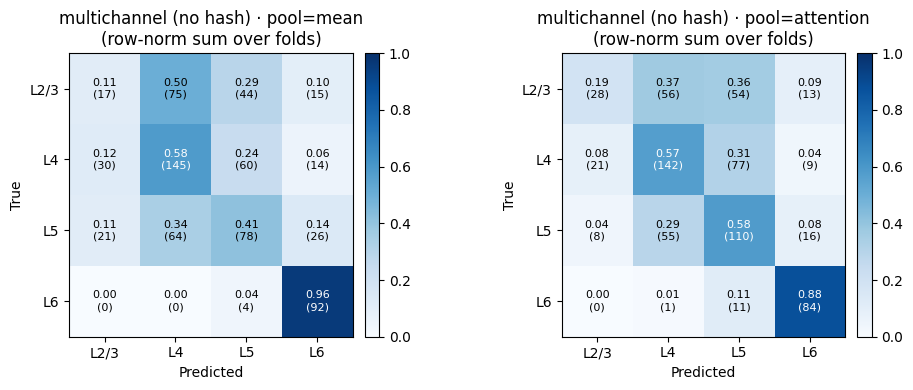

In [11]:
# Confusion matrices — multichannel only (one per pool variant)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, pool in enumerate(POOL_VARIANTS):
    ax = axes[i]
    Cm = sum(s['confusion_matrix'] for s in resultsA[pool])
    Cn = Cm / Cm.sum(axis=1, keepdims=True).clip(min=1)
    im = ax.imshow(Cn, vmin=0, vmax=1, cmap='Blues')
    for ii in range(Cm.shape[0]):
        for jj in range(Cm.shape[1]):
            ax.text(jj, ii, f'{Cn[ii,jj]:.2f}\n({Cm[ii,jj]})',
                    ha='center', va='center', fontsize=8,
                    color='white' if Cn[ii,jj] > 0.5 else 'black')
    ax.set_xticks(range(len(LAYER_CLASSES))); ax.set_xticklabels(LAYER_CLASSES)
    ax.set_yticks(range(len(LAYER_CLASSES))); ax.set_yticklabels(LAYER_CLASSES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'multichannel (no hash) · pool={pool}\n(row-norm sum over folds)')
    plt.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
plt.tight_layout(); plt.show()

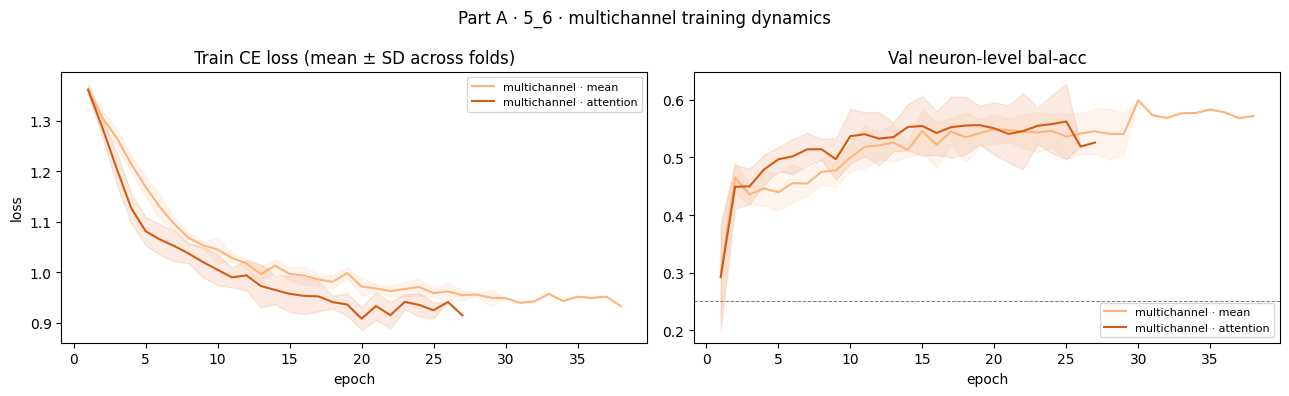

In [12]:
# Training curves — multichannel mean + attention (NB 04 baseline has no per-epoch curves in parquet)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for pool, hists in historiesA.items():
    color = colors[('multichannel', pool)]
    max_e = max(len(h) for h in hists)
    loss = np.full((len(hists), max_e), np.nan)
    vacc = np.full((len(hists), max_e), np.nan)
    for ii, h in enumerate(hists):
        loss[ii, :len(h)] = [r['train_loss']  for r in h]
        vacc[ii, :len(h)] = [r['val_bal_acc'] for r in h]
    epochs = np.arange(1, max_e + 1)
    label  = f'multichannel · {pool}'
    axes[0].plot(epochs, np.nanmean(loss, 0), color=color, label=label)
    axes[0].fill_between(epochs,
                         np.nanmean(loss, 0) - np.nanstd(loss, 0),
                         np.nanmean(loss, 0) + np.nanstd(loss, 0), color=color, alpha=0.12)
    axes[1].plot(epochs, np.nanmean(vacc, 0), color=color, label=label)
    axes[1].fill_between(epochs,
                         np.nanmean(vacc, 0) - np.nanstd(vacc, 0),
                         np.nanmean(vacc, 0) + np.nanstd(vacc, 0), color=color, alpha=0.12)
axes[0].set(title='Train CE loss (mean ± SD across folds)', xlabel='epoch', ylabel='loss')
axes[1].set(title='Val neuron-level bal-acc',                xlabel='epoch')
axes[1].axhline(0.25, color='gray', ls='--', lw=0.7)
for ax in axes: ax.legend(fontsize=8, loc='best')
plt.suptitle(f'Part A · {SESSION_A} · multichannel training dynamics')
plt.tight_layout(); plt.show()

## A.8 · Persist Part A results

In [13]:
rows = []
for pool, scores in resultsA.items():
    note_base = (f'NB 09 Part A {SESSION_A}; multichannel; pool={pool}; in_channels={C_TOTAL}; '
                 f'channels=[calcium,*{ALL_EXTRA_CHANNELS}]; '
                 f'embed_dim={EMBED_DIM} head_hidden={HEAD_HIDDEN} dropout={DROPOUT}; '
                 f'no_hash_embedding=True; loss=inverse_freq')
    model_name = f'DeepSetsCNN_E1_multichannel_tv_{pool}_no_hashemb'
    for k, s in enumerate(scores):
        rows.append(make_result_row(
            model_name      = model_name,
            input_mode      = 'E1_set_padded_oracle_multichannel_no_hash_timevarying',
            normalization   = 'raw_calcium_zscored_extra',
            stimulus_family = 'all_padded',
            split_protocol  = f'within_session_GKF{N_FOLDS}',
            fold_or_session = f'{SESSION_A}_fold{k}',
            seed            = SEED + k,
            score_dict      = s,
            notes           = (note_base +
                                f'; best_epoch={s["best_epoch"]}/{s["n_epochs_run"]};'
                                f' val_test_gap={s["val_minus_test_gap"]:+.3f}'),
        ))
    sm = summariesA[pool]
    rows.append({
        'model_name':        model_name,
        'input_mode':        'E1_set_padded_oracle_multichannel_no_hash_timevarying',
        'normalization':     'raw_calcium_zscored_extra',
        'stimulus_family':   'all_padded',
        'split_protocol':    f'within_session_GKF{N_FOLDS}',
        'fold_or_session':   f'{SESSION_A}_summary',
        'seed':              SEED,
        'n_neurons':         int(np.mean([sc['n_neurons'] for sc in scores])),
        'balanced_accuracy': float(sm['bal_acc'].mean()),
        'macro_f1':          float(sm['macro_f1'].mean()),
        'recall_L23':        float(sm['recall']['L2/3'].mean()),
        'recall_L4':         float(sm['recall']['L4'].mean()),
        'recall_L5':         float(sm['recall']['L5'].mean()),
        'recall_L6':         float(sm['recall']['L6'].mean()),
        'notes':             (f'NB 09 SUMMARY · Part A · multichannel TV · pool={pool}; '
                              f'bal_acc_std={sm["bal_acc"].std(ddof=0):.4f}'),
    })

save_results(rows, 'phase2_multichannel_within_session.parquet')
print(f'Saved {len(rows)} rows → data/processed/results/phase2_multichannel_within_session.parquet')

Saved 12 row(s) → data/processed/results/phase2_multichannel_within_session.parquet  (total: 36)
Saved 12 rows → data/processed/results/phase2_multichannel_within_session.parquet


# Part B — pooled GroupKFold across the 6 balanced sessions

Same architecture, pooled across `5_6, 5_7, 6_2, 6_4, 6_6, 6_7`. Pooled GKF is **stability / model selection**, not the cross-session generalisation test (planning §Stage 2.3a). Behaviour is z-scored using the full pool here — train and test both contain neurons from every session, so this is equivalent to training-fold-only standardisation. The strict held-out-session normalisation kicks in only in Part C.

## B.1 · Pooled E1, channel maps, set tensor

In [14]:
df_B = build_pooled_e1(BALANCED_SESSIONS, units_clean, verbose=True)
cov_B = df_B.groupby('nucleus_id')['condition_hash'].nunique()
incomplete = (cov_B < 116).sum()
if incomplete:
    print(f'\nDropping {incomplete} neurons without full 116-hash coverage')
    df_B = df_B[df_B['nucleus_id'].isin(cov_B.index[cov_B == 116])].copy()
print(f'Pooled E1 rows: {len(df_B):,}  ({df_B["nucleus_id"].nunique()} neurons)')

# Behaviour map for the 6 sessions — kept un-z-scored so Part C can renormalise
beh_map_B_raw = load_behaviour_channels_e1(
    BALANCED_SESSIONS, channels=BEH_CHANNELS, pad_to=MAX_TRACE_LEN, verbose=True,
)

# Standardise behaviour using the FULL pool for Part B (planning §Stage 2.3a)
beh_map_B = {k: dict(v) for k, v in beh_map_B_raw.items()}
print('\nStandardising behaviour channels for Part B (pooled-GKF stats):')
for ch in BEH_CHANNELS:
    vals = np.concatenate([d[ch] for d in beh_map_B.values()])
    mu = float(np.nanmean(vals)); sd = float(np.nanstd(vals)) or 1.0
    print(f'  {ch}: mu={mu:+.4f}  sd={sd:.4f}')
    for k in beh_map_B:
        beh_map_B[k][ch] = ((beh_map_B[k][ch] - mu) / sd).astype(np.float32)

chan_map_B = merge_channel_maps(stim_map_all, beh_map_B)
print(f'\nMerged Part B channel map: {len(chan_map_B)} (session, hash) entries')

X_B, mask_B, y_B, nids_B, hash_ids_B, _, _ = build_e1_neuron_tensors_multichannel(
    df_B, chan_map_B, channel_names=ALL_EXTRA_CHANNELS,
    pad_to=MAX_TRACE_LEN, hash_vocab=HASH_VOCAB,
)
print(f'X_B shape: {X_B.shape}     (N, H, C, T)')

session_lookup_B = (df_B.drop_duplicates('nucleus_id')
                       .set_index('nucleus_id')['session_key'].to_dict())
session_of_B = np.array([session_lookup_B[int(n)] for n in nids_B])
print('\nSession composition (pooled population):')
print(pd.Series(session_of_B).value_counts().sort_index().to_string())

gkf = GroupKFold(n_splits=N_FOLDS)
fold_of_B = np.full(len(nids_B), -1, dtype=np.int8)
for k, (_, te_idx) in enumerate(gkf.split(nids_B, groups=nids_B)):
    fold_of_B[te_idx] = k
print('\nNeurons per pooled fold × layer:')
print(pd.crosstab(fold_of_B, y_B, rownames=['fold']).to_string())

Pooling 6 sessions: ['5_6', '5_7', '6_2', '6_4', '6_6', '6_7']
  Population (mismatch-clean): 4257 neurons
session_key
5_6    685
5_7    696
6_2    734
6_4    824
6_6    606
6_7    712

  Pooled E1 rows: 493,812
  Neurons with data: 4,257
  Oracle coverage per neuron: min=116 median=116 max=116

  Per-session row count:
session_key
5_6    79460
5_7    80736
6_2    85144
6_4    95584
6_6    70296
6_7    82592
Pooled E1 rows: 493,812  (4257 neurons)
Loading behaviour channels ['treadmill', 'pupil_dilation'] for sessions=['5_6', '5_7', '6_2', '6_4', '6_6', '6_7'] ...
  trials_meta rows: 1,680
  trial-averaged (session, hash) pairs: 696 (of 696 possible)
  channel 'treadmill': range [-8.535, 8.693], mean -0.014
  channel 'pupil_dilation': range [0.000, 83.575], mean 28.967

Standardising behaviour channels for Part B (pooled-GKF stats):
  treadmill: mu=-0.0143  sd=0.2978
  pupil_dilation: mu=+28.9673  sd=22.0773

Merged Part B channel map: 696 (session, hash) entries


/Users/katiarusso/Documents/VS CODE/Classes/Neuroscience/Final Project/src/features/raw_traces.py:844: RuntimeWarning: Mean of empty slice
  avg = np.nanmean(stacked, axis=0)


X_B shape: (4257, 116, 10, 113)     (N, H, C, T)

Session composition (pooled population):
5_6    685
5_7    696
6_2    734
6_4    824
6_6    606
6_7    712

Neurons per pooled fold × layer:
col_0  L2/3   L4   L5  L6
fold                     
0       391  187  214  60
1       379  204  210  59
2       374  209  200  68
3       380  205  206  60
4       385  206  203  57


## B.2 · Run pooled GKF — multichannel mean & attention pool

In [15]:
resultsB   = {}
historiesB = {}
fold_times = {}
t0 = time.time()
for pool in POOL_VARIANTS:
    print(f'\n──── Part B · multichannel · pool={pool} · in_channels={C_TOTAL} ────')
    resultsB[pool]   = []
    historiesB[pool] = []
    fold_times[pool] = []
    for k in range(N_FOLDS):
        ti = time.time()
        score, hist = run_design_b_fold(
            X_B, mask_B, y_B, fold_of_B, fold_k=k,
            in_channels=C_TOTAL, pool=pool, seed=SEED, verbose=False,
        )
        elapsed = time.time() - ti
        fold_times[pool].append(elapsed)
        # Per-session breakdown inside this test fold
        test_idx = np.where(fold_of_B == k)[0]
        sess_te  = session_of_B[test_idx]
        y_te     = y_B[test_idx]
        y_pred   = score['y_neuron_pred']
        per_session = {}
        for s in BALANCED_SESSIONS:
            sel = (sess_te == s)
            n_sel = int(sel.sum())
            if n_sel == 0:
                per_session[s] = {'n': 0, 'bal_acc': float('nan'),
                                  'recall': {c: float('nan') for c in LAYER_CLASSES}}
                continue
            ba_s = float(balanced_accuracy_score(y_te[sel], y_pred[sel]))
            cm_s = confusion_matrix(y_te[sel], y_pred[sel], labels=LAYER_CLASSES)
            rec_s = {c: float(cm_s[i, i] / cm_s[i].sum()) if cm_s[i].sum() > 0
                     else float('nan') for i, c in enumerate(LAYER_CLASSES)}
            per_session[s] = {'n': n_sel, 'bal_acc': ba_s, 'recall': rec_s}
        score['per_session']   = per_session
        score['fold']          = k
        score['training_time'] = elapsed
        resultsB[pool].append(score)
        historiesB[pool].append(hist)
        ba = score['balanced_accuracy']; f1 = score['macro_f1']
        print(f'  fold {k} | n_test={score["n_neurons"]:4d} | bal_acc={ba:.4f} F1={f1:.4f}  '
              f'val−test gap={score["val_minus_test_gap"]:+.3f}  '
              f'best_ep={score["best_epoch"]:>2d}/{score["n_epochs_run"]}  '
              f'({elapsed:.1f}s)')
print(f'\nPart B total training time: {(time.time() - t0) / 60:.1f} min')


──── Part B · multichannel · pool=mean · in_channels=10 ────
  fold 0 | n_test= 852 | bal_acc=0.5825 F1=0.4949  val−test gap=-0.005  best_ep=20/28  (375.2s)
  fold 1 | n_test= 852 | bal_acc=0.5610 F1=0.4869  val−test gap=+0.023  best_ep=30/38  (483.7s)
  fold 2 | n_test= 851 | bal_acc=0.5902 F1=0.5045  val−test gap=+0.007  best_ep=43/50  (2052.6s)
  fold 3 | n_test= 851 | bal_acc=0.5804 F1=0.4473  val−test gap=-0.004  best_ep=19/27  (2246.4s)
  fold 4 | n_test= 851 | bal_acc=0.5931 F1=0.5045  val−test gap=+0.005  best_ep=30/38  (22521.7s)

──── Part B · multichannel · pool=attention · in_channels=10 ────
  fold 0 | n_test= 852 | bal_acc=0.6262 F1=0.5431  val−test gap=-0.005  best_ep=32/40  (21539.8s)
  fold 1 | n_test= 852 | bal_acc=0.6182 F1=0.5456  val−test gap=+0.007  best_ep=34/42  (1207.9s)
  fold 2 | n_test= 851 | bal_acc=0.6120 F1=0.5430  val−test gap=+0.006  best_ep=33/41  (387.7s)
  fold 3 | n_test= 851 | bal_acc=0.6072 F1=0.5220  val−test gap=-0.007  best_ep=26/34  (3247.4s)

## B.3 · Load NB 07 baseline + pooled-GKF summary

In [16]:
baselineB = load_baseline_rows(
    NB07_PARQUET,
    contains_filter='attnpool',
    fold_filter='fold',
)
if baselineB is not None:
    baselineB = baselineB.sort_values('fold_or_session').reset_index(drop=True).iloc[:N_FOLDS]
    print(f'NB 07 hash-aware attnpool baseline ({len(baselineB)} rows): '
          f"bal_acc = {baselineB['balanced_accuracy'].mean():.4f} ± "
          f"{baselineB['balanced_accuracy'].std(ddof=0):.4f}")
else:
    print(f'⚠ NB 07 baseline not found in {NB07_PARQUET}')

summariesB = {pool: summarise(scores) for pool, scores in resultsB.items()}
rows = []
for pool in POOL_VARIANTS:
    sm = summariesB[pool]
    rows.append({
        'config': f'multichannel_no_hash · {pool}',
        'channels': C_TOTAL,
        'bal_acc':  fmt_arr(sm['bal_acc']),
        'macro_F1': fmt_arr(sm['macro_f1']),
        'L2/3':     fmt_recall(sm['recall']['L2/3']),
        'L4':       fmt_recall(sm['recall']['L4']),
        'L5':       fmt_recall(sm['recall']['L5']),
        'L6':       fmt_recall(sm['recall']['L6']),
    })
if baselineB is not None:
    b = baselineB
    rows.append({
        'config': 'NB 07 hash-aware (calcium-only) · attention',
        'channels': 1,
        'bal_acc':  f"{b['balanced_accuracy'].mean():.4f} ± {b['balanced_accuracy'].std(ddof=0):.4f}",
        'macro_F1': f"{b['macro_f1'].mean():.4f} ± {b['macro_f1'].std(ddof=0):.4f}",
        'L2/3':     f"{b['recall_L23'].mean():.3f} ± {b['recall_L23'].std(ddof=0):.3f}",
        'L4':       f"{b['recall_L4'].mean():.3f} ± {b['recall_L4'].std(ddof=0):.3f}",
        'L5':       f"{b['recall_L5'].mean():.3f} ± {b['recall_L5'].std(ddof=0):.3f}",
        'L6':       f"{b['recall_L6'].mean():.3f} ± {b['recall_L6'].std(ddof=0):.3f}",
    })
print(f'NB 09 · Part B (pooled GKF{N_FOLDS} across {BALANCED_SESSIONS})\n')
print(pd.DataFrame(rows).set_index('config').to_string())

# Predicted-class distribution (pooled across folds, multichannel only)
print('\nPredicted-class distribution (multichannel · pooled across folds):')
for pool in POOL_VARIANTS:
    pooled_pred = np.concatenate([s['y_neuron_pred'] for s in resultsB[pool]])
    pooled_true = np.concatenate([s['y_neuron_true'] for s in resultsB[pool]])
    pred_counts = pd.Series(pooled_pred).value_counts().reindex(LAYER_CLASSES, fill_value=0)
    true_counts = pd.Series(pooled_true).value_counts().reindex(LAYER_CLASSES, fill_value=0)
    print(f'  pool={pool}')
    print(pd.DataFrame({'true': true_counts, 'pred': pred_counts}).to_string())

# Validation-test gap and average training time
print('\nVal−test gap (mean across folds) and training time (s/fold):')
for pool in POOL_VARIANTS:
    gap_mean = np.mean([s['val_minus_test_gap'] for s in resultsB[pool]])
    tt_mean  = np.mean(fold_times[pool])
    print(f'  multichannel · {pool:<10s}: '
          f'val−test gap = {gap_mean:+.4f}   |   train time = {tt_mean:5.1f}s')

NB 07 hash-aware attnpool baseline (5 rows): bal_acc = 0.5589 ± 0.0172
NB 09 · Part B (pooled GKF5 across ['5_6', '5_7', '6_2', '6_4', '6_6', '6_7'])

                                             channels          bal_acc         macro_F1           L2/3             L4             L5             L6
config                                                                                                                                             
multichannel_no_hash · mean                        10  0.5814 ± 0.0113  0.4876 ± 0.0212  0.222 ± 0.042  0.618 ± 0.056  0.579 ± 0.042  0.907 ± 0.046
multichannel_no_hash · attention                   10  0.6114 ± 0.0110  0.5378 ± 0.0086  0.278 ± 0.024  0.646 ± 0.038  0.618 ± 0.042  0.903 ± 0.045
NB 07 hash-aware (calcium-only) · attention         1  0.5589 ± 0.0172  0.4693 ± 0.0207  0.168 ± 0.109  0.553 ± 0.141  0.614 ± 0.041  0.900 ± 0.043

Predicted-class distribution (multichannel · pooled across folds):
  pool=mean
      true  pred
L2/3  1909  

## B.4 · Per-session breakdown inside each test fold (multichannel)

In [17]:
for pool in POOL_VARIANTS:
    print(f'\nPool = {pool} · per-session test bal-acc inside each GKF fold:')
    rows = []
    for k, score in enumerate(resultsB[pool]):
        row = {'fold': k}
        for s in BALANCED_SESSIONS:
            ent = score['per_session'][s]
            row[f'{s}_n']   = ent['n']
            row[f'{s}_bal'] = (f'{ent["bal_acc"]:.3f}'
                               if np.isfinite(ent['bal_acc']) else '—')
        rows.append(row)
    print(pd.DataFrame(rows).set_index('fold').to_string())

print('\nMean per-session bal-acc (multichannel) — pooled GKF:')
for pool in POOL_VARIANTS:
    rows = []
    for s in BALANCED_SESSIONS:
        bas = []; ns = []
        for sc in resultsB[pool]:
            ns.append(sc['per_session'][s]['n'])
            bas.append(sc['per_session'][s]['bal_acc'])
        bas = np.array(bas, dtype=float)
        rows.append({
            'session': s,
            'mean_n_per_fold': int(np.nanmean(ns)),
            'bal_acc_mean':    f'{np.nanmean(bas):.3f}',
            'bal_acc_std':     f'{np.nanstd(bas):.3f}',
        })
    print(f'  pool = {pool}')
    print(pd.DataFrame(rows).set_index('session').to_string())


Pool = mean · per-session test bal-acc inside each GKF fold:
      5_6_n 5_6_bal  5_7_n 5_7_bal  6_2_n 6_2_bal  6_4_n 6_4_bal  6_6_n 6_6_bal  6_7_n 6_7_bal
fold                                                                                          
0       143   0.565    126   0.546    153   0.567    182   0.560    113   0.497    135   0.526
1       132   0.583    147   0.557    137   0.614    142   0.513    138   0.498    156   0.350
2       136   0.618    141   0.577    151   0.638    160   0.526    117   0.472    146   0.430
3       146   0.559    134   0.522    149   0.601    172   0.619    111   0.425    139   0.520
4       128   0.572    148   0.590    144   0.596    168   0.550    127   0.530    136   0.444

Pool = attention · per-session test bal-acc inside each GKF fold:
      5_6_n 5_6_bal  5_7_n 5_7_bal  6_2_n 6_2_bal  6_4_n 6_4_bal  6_6_n 6_6_bal  6_7_n 6_7_bal
fold                                                                                          
0       143   0.

## B.5 · Persist Part B results

In [18]:
rows = []
for pool, scores in resultsB.items():
    note_base = (f'NB 09 Part B pooled GKF on {BALANCED_SESSIONS}; multichannel; pool={pool}; '
                 f'in_channels={C_TOTAL}; no_hash_embedding=True; '
                 f'channels=[calcium,*{ALL_EXTRA_CHANNELS}]')
    model_name = f'DeepSetsCNN_E1_multichannel_tv_{pool}_no_hashemb'
    for k, s in enumerate(scores):
        rows.append(make_result_row(
            model_name      = model_name,
            input_mode      = 'E1_set_padded_oracle_multichannel_no_hash_timevarying',
            normalization   = 'raw_calcium_zscored_extra',
            stimulus_family = 'all_padded',
            split_protocol  = f'pooled_GKF{N_FOLDS}',
            fold_or_session = f'pooled_fold{k}',
            seed            = SEED + k,
            score_dict      = s,
            notes           = (note_base +
                                f'; best_epoch={s["best_epoch"]}/{s["n_epochs_run"]};'
                                f' val_test_gap={s["val_minus_test_gap"]:+.3f};'
                                f' time={s["training_time"]:.1f}s'),
        ))
    sm = summariesB[pool]
    rows.append({
        'model_name':        model_name,
        'input_mode':        'E1_set_padded_oracle_multichannel_no_hash_timevarying',
        'normalization':     'raw_calcium_zscored_extra',
        'stimulus_family':   'all_padded',
        'split_protocol':    f'pooled_GKF{N_FOLDS}',
        'fold_or_session':   'pooled_summary',
        'seed':              SEED,
        'n_neurons':         int(np.mean([sc['n_neurons'] for sc in scores])),
        'balanced_accuracy': float(sm['bal_acc'].mean()),
        'macro_f1':          float(sm['macro_f1'].mean()),
        'recall_L23':        float(sm['recall']['L2/3'].mean()),
        'recall_L4':         float(sm['recall']['L4'].mean()),
        'recall_L5':         float(sm['recall']['L5'].mean()),
        'recall_L6':         float(sm['recall']['L6'].mean()),
        'notes':             (f'NB 09 SUMMARY · Part B · multichannel TV · pool={pool}; '
                              f'bal_acc_std={sm["bal_acc"].std(ddof=0):.4f}'),
    })

save_results(rows, 'phase2_multichannel_pooled_gkf.parquet')
print(f'Saved {len(rows)} rows → data/processed/results/phase2_multichannel_pooled_gkf.parquet')

Saved 12 row(s) → data/processed/results/phase2_multichannel_pooled_gkf.parquet  (total: 12)
Saved 12 rows → data/processed/results/phase2_multichannel_pooled_gkf.parquet


# Part C — Leave-One-Session-Out across the 6 balanced sessions

For each held-out session $s$, we:
1. Define training sessions = `BALANCED_SESSIONS \ {s}`.
2. Z-score behaviour channels using **only training-session entries** (never the held-out session).
3. Re-build the merged channel map and the multichannel set tensor with these per-fold-standardised behaviour values.
4. Train Design B on training neurons (with a stratified 15% val carve-out) and test on held-out-session neurons.

Stimulus channels are session-invariant by construction, so their normalisation is fold-independent.

## C.1 · Choose LOSO pool(s) from Part B's stability metric

In [19]:
VAL_GAP_THRESHOLD = 0.04
ATTN_OVER_MEAN_PP = 0.02
mc_mean_ba = summariesB['mean']['bal_acc'].mean()
mc_attn_ba = summariesB['attention']['bal_acc'].mean()
mc_mean_gap = np.mean([s['val_minus_test_gap'] for s in resultsB['mean']])
mc_attn_gap = np.mean([s['val_minus_test_gap'] for s in resultsB['attention']])

LOSO_POOLS = ['mean']
if (mc_attn_ba >= mc_mean_ba + ATTN_OVER_MEAN_PP) and (abs(mc_attn_gap) <= VAL_GAP_THRESHOLD):
    LOSO_POOLS.append('attention')
print(f'Part B mean      pool: bal_acc={mc_mean_ba:.4f}, val−test gap={mc_mean_gap:+.4f}')
print(f'Part B attention pool: bal_acc={mc_attn_ba:.4f}, val−test gap={mc_attn_gap:+.4f}')
print(f'\nLOSO will run pools: {LOSO_POOLS}')

Part B mean      pool: bal_acc=0.5814, val−test gap=+0.0051
Part B attention pool: bal_acc=0.6114, val−test gap=+0.0064

LOSO will run pools: ['mean', 'attention']


## C.2 · LOSO runner — rebuilds the multichannel tensor *per fold* with train-only behaviour z-score

In [20]:
def run_loso_one_session(test_session, *, in_channels, pool, seed, val_fraction=0.15,
                          verbose=False):
    """One LOSO fit with training-session-only behaviour normalisation.

    Steps:
    1. Build a fresh chan_map for this fold by z-scoring behaviour using only
       (session ≠ test_session) entries.
    2. Re-build the multichannel set tensor X with these channels.
    3. Train Design B with a stratified 15% val carved from training neurons.
    """
    train_sessions = [s for s in BALANCED_SESSIONS if s != test_session]
    chan_map_fold = zscore_behaviour_for_loso_fold(
        merge_channel_maps(stim_map_all, beh_map_B_raw),
        train_sessions, BEH_CHANNELS,
    )
    X_loso, mask_loso, y_loso, nids_loso, hash_ids_loso, _, _ = (
        build_e1_neuron_tensors_multichannel(
            df_B, chan_map_fold, channel_names=ALL_EXTRA_CHANNELS,
            pad_to=MAX_TRACE_LEN, hash_vocab=HASH_VOCAB,
        )
    )
    sess_arr = np.array([session_lookup_B[int(n)] for n in nids_loso])

    test_idx = np.where(sess_arr == test_session)[0]
    pool_idx = np.where(sess_arr != test_session)[0]
    if len(test_idx) == 0:
        raise ValueError(f'No neurons for held-out session {test_session!r}')

    rng = np.random.default_rng(seed)
    val_idx_list = []
    for cls in LAYER_CLASSES:
        cls_idx = pool_idx[y_loso[pool_idx] == cls]
        n_val = max(1, int(round(len(cls_idx) * val_fraction)))
        rng.shuffle(cls_idx)
        val_idx_list.append(cls_idx[:n_val])
    val_idx   = np.concatenate(val_idx_list)
    train_idx = np.setdiff1d(pool_idx, val_idx, assume_unique=False)

    X_tr, M_tr, y_tr = X_loso[train_idx], mask_loso[train_idx], y_loso[train_idx]
    X_va, M_va, y_va = X_loso[val_idx],   mask_loso[val_idx],   y_loso[val_idx]
    X_te, M_te, y_te = X_loso[test_idx],  mask_loso[test_idx],  y_loso[test_idx]

    model, history = train_design_b_fold(
        X_tr, M_tr, y_tr, X_va, M_va, y_va,
        in_channels=in_channels, n_classes=4,
        embed_dim=EMBED_DIM, head_hidden=HEAD_HIDDEN,
        dropout=DROPOUT, kernel_size=KERNEL_SIZE,
        pool=pool,
        batch_size=BATCH_SIZE, max_epochs=MAX_EPOCHS, patience=PATIENCE,
        lr=1e-3, weight_decay=1e-4,
        seed=seed, device=DEVICE, verbose=verbose,
    )

    test_probs = predict_neuron_proba(model, X_te, mask=M_te,
                                      batch_size=BATCH_SIZE, device=DEVICE)
    val_probs  = predict_neuron_proba(model, X_va, mask=M_va,
                                      batch_size=BATCH_SIZE, device=DEVICE)
    score = neuron_score_with_dist(y_te, test_probs, classes=np.array(LAYER_CLASSES))
    val_pred = np.array(LAYER_CLASSES)[val_probs.argmax(axis=1)]
    score['val_balanced_accuracy'] = float(balanced_accuracy_score(y_va, val_pred))
    score['val_macro_f1']          = float(f1_score(y_va, val_pred, average='macro',
                                                     labels=LAYER_CLASSES, zero_division=0))
    score['val_minus_test_gap']    = score['val_balanced_accuracy'] - score['balanced_accuracy']
    score['n_train']               = int(len(train_idx))
    score['n_val']                 = int(len(val_idx))
    score['best_epoch']            = int(np.argmax([h['val_bal_acc'] for h in history])) + 1
    score['n_epochs_run']          = len(history)
    return score, history

print('LOSO runner ready (rebuilds tensor per fold with training-session-only behaviour z-score).')

LOSO runner ready (rebuilds tensor per fold with training-session-only behaviour z-score).


## C.3 · Run LOSO multichannel for the chosen pool(s)

In [21]:
resultsC   = {}
historiesC = {}
loso_times = {}

t0 = time.time()
for pool in LOSO_POOLS:
    print(f'\n──── Part C LOSO · multichannel · pool={pool} · in_channels={C_TOTAL} ────')
    resultsC[pool]   = []
    historiesC[pool] = []
    loso_times[pool] = []
    for i, test_sess in enumerate(BALANCED_SESSIONS):
        ti = time.time()
        score, hist = run_loso_one_session(
            test_session=test_sess, in_channels=C_TOTAL, pool=pool,
            seed=SEED + i, verbose=False,
        )
        elapsed = time.time() - ti
        loso_times[pool].append(elapsed)
        score['test_session']  = test_sess
        score['training_time'] = elapsed
        resultsC[pool].append(score)
        historiesC[pool].append(hist)

        ba = score['balanced_accuracy']; f1 = score['macro_f1']
        pcr = score['per_class_recall']
        print(f'  test={test_sess} | n_test={score["n_neurons"]:3d} | '
              f'bal_acc={ba:.4f} F1={f1:.4f}  '
              f'val−test gap={score["val_minus_test_gap"]:+.3f}  '
              f'L23={pcr["L2/3"]:.2f} L4={pcr["L4"]:.2f} L5={pcr["L5"]:.2f} L6={pcr["L6"]:.2f}  '
              f'best_ep={score["best_epoch"]:>2d}/{score["n_epochs_run"]}  '
              f'({elapsed:.1f}s)')
print(f'\nPart C total LOSO training time: {(time.time() - t0) / 60:.1f} min')


──── Part C LOSO · multichannel · pool=mean · in_channels=10 ────
  test=5_6 | n_test=685 | bal_acc=0.4820 F1=0.3552  val−test gap=+0.101  L23=0.43 L4=0.00 L5=0.52 L6=0.98  best_ep=18/26  (296.0s)
  test=5_7 | n_test=696 | bal_acc=0.5584 F1=0.4768  val−test gap=+0.026  L23=0.07 L4=0.62 L5=0.62 L6=0.93  best_ep=13/21  (236.1s)
  test=6_2 | n_test=734 | bal_acc=0.5903 F1=0.4628  val−test gap=-0.000  L23=0.07 L4=0.61 L5=0.68 L6=1.00  best_ep=19/27  (309.6s)
  test=6_4 | n_test=824 | bal_acc=0.5164 F1=0.3172  val−test gap=+0.125  L23=0.01 L4=0.79 L5=0.45 L6=0.82  best_ep=21/29  (314.2s)
  test=6_6 | n_test=606 | bal_acc=0.4661 F1=0.2277  val−test gap=+0.168  L23=0.00 L4=0.79 L5=0.21 L6=0.86  best_ep=50/50  (577.2s)
  test=6_7 | n_test=712 | bal_acc=0.4853 F1=0.2369  val−test gap=+0.080  L23=0.12 L4=0.58 L5=0.31 L6=0.93  best_ep=29/37  (421.5s)

──── Part C LOSO · multichannel · pool=attention · in_channels=10 ────
  test=5_6 | n_test=685 | bal_acc=0.5458 F1=0.4502  val−test gap=+0.072  L2

## C.4 · Load NB 08 baseline and summarise LOSO

In [22]:
baselineC = load_baseline_rows(
    NB08_PARQUET,
    contains_filter='attnpool',
    fold_filter='',     # NB 08 uses session names directly in fold_or_session
)
if baselineC is not None:
    # Keep only rows whose fold_or_session matches one of our 6 balanced sessions
    baselineC = baselineC[baselineC['fold_or_session'].apply(
        lambda x: any(s in str(x) for s in BALANCED_SESSIONS)
    )].copy().reset_index(drop=True)
    # Map the row to the session string
    def _which_session(row):
        for s in BALANCED_SESSIONS:
            if s in str(row['fold_or_session']):
                return s
        return None
    baselineC['session'] = baselineC.apply(_which_session, axis=1)
    baselineC = baselineC.dropna(subset=['session'])
    print(f'NB 08 hash-aware attnpool baseline ({len(baselineC)} rows): '
          f"mean bal_acc = {baselineC['balanced_accuracy'].mean():.4f} ± "
          f"{baselineC['balanced_accuracy'].std(ddof=0):.4f}")
else:
    print(f'⚠ NB 08 baseline not found in {NB08_PARQUET}')

summariesC = {}
for pool, scores in resultsC.items():
    bas = np.array([s['balanced_accuracy'] for s in scores])
    f1s = np.array([s['macro_f1']          for s in scores])
    pcr = {c: np.array([s['per_class_recall'][c] for s in scores]) for c in LAYER_CLASSES}
    summariesC[pool] = {'bal_acc': bas, 'macro_f1': f1s, 'recall': pcr}

print(f'\nNB 09 · Part C LOSO ({BALANCED_SESSIONS})\n')
for pool in LOSO_POOLS:
    print(f'─── multichannel · pool = {pool} ───')
    rows = []
    for s in resultsC[pool]:
        rows.append({
            'test_session': s['test_session'],
            'n_test':       s['n_neurons'],
            'bal_acc':      f'{s["balanced_accuracy"]:.4f}',
            'macro_F1':     f'{s["macro_f1"]:.4f}',
            'recall_L23':   f'{s["per_class_recall"]["L2/3"]:.3f}',
            'recall_L4':    f'{s["per_class_recall"]["L4"]:.3f}',
            'recall_L5':    f'{s["per_class_recall"]["L5"]:.3f}',
            'recall_L6':    f'{s["per_class_recall"]["L6"]:.3f}',
            'val_test_gap': f'{s["val_minus_test_gap"]:+.3f}',
        })
    sub = summariesC[pool]
    rows.append({
        'test_session': 'MEAN',
        'n_test':       int(np.mean([s['n_neurons'] for s in resultsC[pool]])),
        'bal_acc':      f'{sub["bal_acc"].mean():.4f} ± {sub["bal_acc"].std(ddof=0):.4f}',
        'macro_F1':     f'{sub["macro_f1"].mean():.4f} ± {sub["macro_f1"].std(ddof=0):.4f}',
        'recall_L23':   f'{np.nanmean(sub["recall"]["L2/3"]):.3f}',
        'recall_L4':    f'{np.nanmean(sub["recall"]["L4"]):.3f}',
        'recall_L5':    f'{np.nanmean(sub["recall"]["L5"]):.3f}',
        'recall_L6':    f'{np.nanmean(sub["recall"]["L6"]):.3f}',
        'val_test_gap': f'{np.mean([s["val_minus_test_gap"] for s in resultsC[pool]]):+.3f}',
    })
    print(pd.DataFrame(rows).set_index('test_session').to_string())
    print()

NB 08 hash-aware attnpool baseline (6 rows): mean bal_acc = 0.5217 ± 0.0522

NB 09 · Part C LOSO (['5_6', '5_7', '6_2', '6_4', '6_6', '6_7'])

─── multichannel · pool = mean ───
              n_test          bal_acc         macro_F1 recall_L23 recall_L4 recall_L5 recall_L6 val_test_gap
test_session                                                                                                
5_6              685           0.4820           0.3552      0.430     0.000     0.519     0.979       +0.101
5_7              696           0.5584           0.4768      0.065     0.623     0.619     0.926       +0.026
6_2              734           0.5903           0.4628      0.067     0.614     0.680     1.000       -0.000
6_4              824           0.5164           0.3172      0.009     0.787     0.450     0.820       +0.125
6_6              606           0.4661           0.2277      0.000     0.792     0.211     0.862       +0.168
6_7              712           0.4853           0.2369     

## C.5 · Paired Δ vs NB 08 hash-aware baseline (per held-out session)

In [23]:
if baselineC is not None:
    bC = baselineC.set_index('session')
    for pool in LOSO_POOLS:
        rows = []
        mc = summariesC[pool]
        for i, s in enumerate(BALANCED_SESSIONS):
            if s not in bC.index:
                continue
            d_ba  = mc['bal_acc'][i]   - bC.loc[s, 'balanced_accuracy']
            d_f1  = mc['macro_f1'][i]  - bC.loc[s, 'macro_f1']
            d_l23 = mc['recall']['L2/3'][i] - bC.loc[s, 'recall_L23']
            d_l4  = mc['recall']['L4'][i]  - bC.loc[s, 'recall_L4']
            d_l5  = mc['recall']['L5'][i]  - bC.loc[s, 'recall_L5']
            d_l6  = mc['recall']['L6'][i]  - bC.loc[s, 'recall_L6']
            rows.append({
                'test_session':  s,
                'mc_bal_acc':    f'{mc["bal_acc"][i]:.4f}',
                'NB08_bal_acc':  f'{bC.loc[s, "balanced_accuracy"]:.4f}',
                'Δ_bal_acc':     f'{d_ba:+.4f}',
                'Δ_macro_F1':    f'{d_f1:+.4f}',
                'Δ_recall_L2/3': f'{d_l23:+.3f}',
                'Δ_recall_L4':   f'{d_l4:+.3f}',
                'Δ_recall_L5':   f'{d_l5:+.3f}',
                'Δ_recall_L6':   f'{d_l6:+.3f}',
            })
        # Mean row
        d_ba_all = np.array([
            mc['bal_acc'][i] - bC.loc[s, 'balanced_accuracy']
            for i, s in enumerate(BALANCED_SESSIONS) if s in bC.index
        ])
        d_f1_all = np.array([
            mc['macro_f1'][i] - bC.loc[s, 'macro_f1']
            for i, s in enumerate(BALANCED_SESSIONS) if s in bC.index
        ])
        rows.append({
            'test_session':  'MEAN',
            'mc_bal_acc':    f'{mc["bal_acc"].mean():.4f}',
            'NB08_bal_acc':  f'{bC["balanced_accuracy"].mean():.4f}',
            'Δ_bal_acc':     f'{d_ba_all.mean():+.4f}',
            'Δ_macro_F1':    f'{d_f1_all.mean():+.4f}',
            'Δ_recall_L2/3': '',
            'Δ_recall_L4':   '',
            'Δ_recall_L5':   '',
            'Δ_recall_L6':   '',
        })
        print(f'\nPaired Δ (multichannel · {pool} − NB 08 hash-aware attnpool):')
        print(pd.DataFrame(rows).set_index('test_session').to_string())
else:
    print('⚠ NB 08 baseline absent — paired Δ skipped.')


Paired Δ (multichannel · mean − NB 08 hash-aware attnpool):
             mc_bal_acc NB08_bal_acc Δ_bal_acc Δ_macro_F1 Δ_recall_L2/3 Δ_recall_L4 Δ_recall_L5 Δ_recall_L6
test_session                                                                                               
5_6              0.4820       0.5557   -0.0737    -0.1687        +0.179      -0.394      -0.122      +0.042
5_7              0.5584       0.5632   -0.0048    -0.0198        +0.000      -0.042      +0.048      -0.025
6_2              0.5903       0.5709   +0.0194    -0.0852        -0.280      +0.161      -0.046      +0.242
6_4              0.5164       0.5267   -0.0102    -0.0501        -0.027      +0.066      -0.240      +0.160
6_6              0.4661       0.4928   -0.0268    -0.1362        -0.219      +0.417      -0.270      -0.034
6_7              0.4853       0.4209   +0.0644    -0.0791        -0.221      +0.346      -0.068      +0.200
MEAN             0.5164       0.5217   -0.0053    -0.0898                  

## C.6 · LOSO confusion matrices and pooled-GKF → LOSO drop

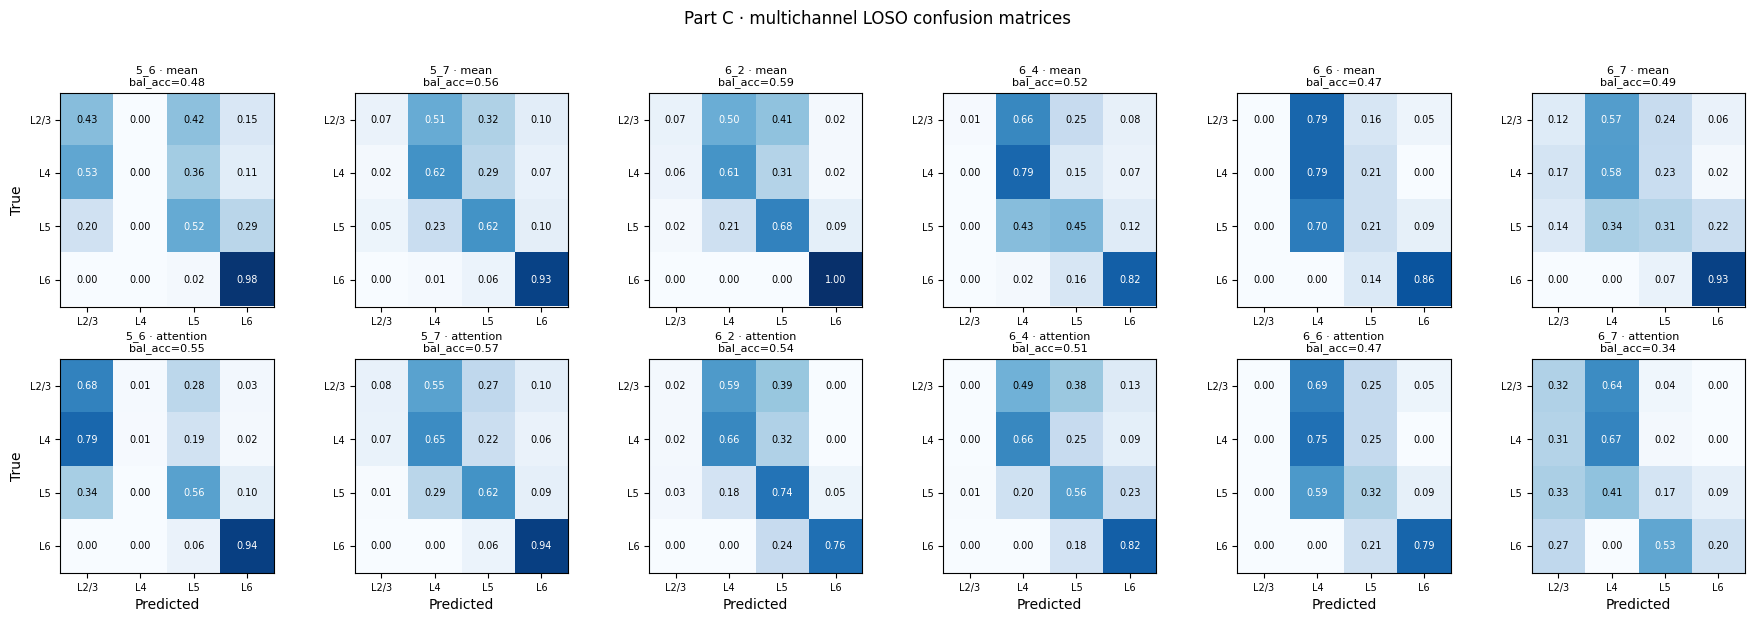


Pooled-GKF → LOSO drop (multichannel only):
          pooled_GKF_bal_acc LOSO_bal_acc GKF→LOSO drop
pool                                                   
mean                  0.5814       0.5164       +0.0650
attention             0.6114       0.4967       +0.1148


In [24]:
fig, axes = plt.subplots(len(LOSO_POOLS), len(BALANCED_SESSIONS),
                          figsize=(3 * len(BALANCED_SESSIONS), 3 * len(LOSO_POOLS)),
                          squeeze=False)
for r, pool in enumerate(LOSO_POOLS):
    scores = resultsC[pool]
    for c, s in enumerate(scores):
        ax = axes[r, c]
        Cm = s['confusion_matrix']
        Cn = Cm / Cm.sum(axis=1, keepdims=True).clip(min=1)
        ax.imshow(Cn, vmin=0, vmax=1, cmap='Blues')
        for ii in range(Cm.shape[0]):
            for jj in range(Cm.shape[1]):
                ax.text(jj, ii, f'{Cn[ii,jj]:.2f}',
                        ha='center', va='center', fontsize=7,
                        color='white' if Cn[ii,jj] > 0.5 else 'black')
        ax.set_xticks(range(len(LAYER_CLASSES))); ax.set_xticklabels(LAYER_CLASSES, fontsize=7)
        ax.set_yticks(range(len(LAYER_CLASSES))); ax.set_yticklabels(LAYER_CLASSES, fontsize=7)
        ax.set_title(f'{s["test_session"]} · {pool}\nbal_acc={s["balanced_accuracy"]:.2f}',
                     fontsize=8)
        if c == 0: ax.set_ylabel('True')
        if r == len(LOSO_POOLS) - 1: ax.set_xlabel('Predicted')
plt.suptitle('Part C · multichannel LOSO confusion matrices', y=1.02)
plt.tight_layout(); plt.show()

print('\nPooled-GKF → LOSO drop (multichannel only):')
rows = []
for pool in POOL_VARIANTS:
    if pool not in summariesC:
        continue
    gkf_ba = summariesB[pool]['bal_acc'].mean()
    los_ba = summariesC[pool]['bal_acc'].mean()
    rows.append({
        'pool': pool,
        'pooled_GKF_bal_acc': f'{gkf_ba:.4f}',
        'LOSO_bal_acc':       f'{los_ba:.4f}',
        'GKF→LOSO drop':      f'{gkf_ba - los_ba:+.4f}',
    })
print(pd.DataFrame(rows).set_index('pool').to_string())

## C.7 · Persist Part C results

In [25]:
rows = []
for pool, scores in resultsC.items():
    note_base = (f'NB 09 Part C LOSO on {BALANCED_SESSIONS}; multichannel; pool={pool}; '
                 f'in_channels={C_TOTAL}; no_hash_embedding=True; '
                 f'val_fraction=0.15 (stratified); '
                 f'behaviour_normalisation=train_sessions_only')
    model_name = f'DeepSetsCNN_E1_multichannel_tv_{pool}_no_hashemb_LOSO'
    for s in scores:
        rows.append(make_result_row(
            model_name      = model_name,
            input_mode      = 'E1_set_padded_oracle_multichannel_no_hash_timevarying',
            normalization   = 'raw_calcium_zscored_extra_train_only_loso',
            stimulus_family = 'all_padded',
            split_protocol  = 'LOSO_balanced',
            fold_or_session = s['test_session'],
            seed            = SEED + BALANCED_SESSIONS.index(s['test_session']),
            score_dict      = s,
            notes           = (note_base +
                                f'; best_epoch={s["best_epoch"]}/{s["n_epochs_run"]};'
                                f' val_test_gap={s["val_minus_test_gap"]:+.3f};'
                                f' time={s["training_time"]:.1f}s'),
        ))
    sub = summariesC[pool]
    rows.append({
        'model_name':        model_name,
        'input_mode':        'E1_set_padded_oracle_multichannel_no_hash_timevarying',
        'normalization':     'raw_calcium_zscored_extra_train_only_loso',
        'stimulus_family':   'all_padded',
        'split_protocol':    'LOSO_balanced',
        'fold_or_session':   'LOSO_summary',
        'seed':              SEED,
        'n_neurons':         int(np.mean([s['n_neurons'] for s in scores])),
        'balanced_accuracy': float(sub['bal_acc'].mean()),
        'macro_f1':          float(sub['macro_f1'].mean()),
        'recall_L23':        float(np.nanmean(sub['recall']['L2/3'])),
        'recall_L4':         float(np.nanmean(sub['recall']['L4'])),
        'recall_L5':         float(np.nanmean(sub['recall']['L5'])),
        'recall_L6':         float(np.nanmean(sub['recall']['L6'])),
        'notes':             (f'NB 09 SUMMARY · Part C · multichannel TV · pool={pool}; '
                              f'bal_acc_std={sub["bal_acc"].std(ddof=0):.4f}'),
    })

save_results(rows, 'phase2_multichannel_loso.parquet')
print(f'Saved {len(rows)} rows → data/processed/results/phase2_multichannel_loso.parquet')

Saved 14 row(s) → data/processed/results/phase2_multichannel_loso.parquet  (total: 14)
Saved 14 rows → data/processed/results/phase2_multichannel_loso.parquet


---

## What this notebook claims and does *not* claim

* **Compared against** the *hash-aware* Design B baselines from NBs 04 / 07 / 08 (loaded, not retrained). The Δ measures whether time-varying stimulus + behaviour channels can replace the categorical hash embedding while remaining interpretable.
* **Stimulus channels are time-varying** — computed per frame from the raw oracle videos, not broadcast scalars.
* **Behaviour channels are time-varying** — trial-averaged inside each `(session, hash)`, exactly the trials used to build E1.
* **LOSO behaviour normalisation uses only training sessions** for each held-out fold. Stimulus channels are session-invariant by construction so their normalisation is fold-independent.
* **Cannot claim from this notebook alone** that the temporal *dynamics* of any channel matter — that requires the time-shuffled / amplitude-only controls (planning §5), deferred until any multichannel model is scientifically competitive at LOSO.

## Possible follow-ups
1. Channel-ablation at LOSO (drop stim only, drop behaviour only) to attribute the LOSO gain.
2. Add hash embeddings on top of the time-varying channels as a controlled ablation.
3. Replicate Part A on session 5_7.
4. E0 multichannel: trial-level multichannel input.